In [ ]:
# ── Cell 1: GPU check ─────────────────────────────────────────────
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else ' No GPU detected')

Sat Apr 11 23:32:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.nn import functional as F
import time, os, json, urllib.request, psutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import warnings; warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device.upper()}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'RAM     : {psutil.virtual_memory().total/1e9:.1f} GB')

Device  : CUDA
GPU     : Tesla T4
VRAM    : 15.6 GB
RAM     : 13.6 GB


In [3]:
# ── Cell 3: Dataset ───────────────────────────────────────────────
if not os.path.exists('input.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'input.txt'
    )
    print('Downloaded tiny shakespeare')

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi       = {ch: i for i, ch in enumerate(chars)}
itos       = {i: ch for i, ch in enumerate(chars)}
encode     = lambda s: [stoi[c] for c in s]
decode     = lambda l: ''.join([itos[i] for i in l])

data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f'Vocab: {vocab_size} | Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens')

Downloaded tiny shakespeare
Vocab: 65 | Train: 1,003,854 tokens | Val: 111,540 tokens


In [4]:
# ── Cell 4: Hyperparameters & experiment configs ──────────────────
BATCH_SIZE    = 64
BLOCK_SIZE    = 256
MAX_ITERS     = 3000
EVAL_INTERVAL = 300
EVAL_ITERS    = 100
LEARNING_RATE = 3e-4
N_LAYER       = 6
N_EMBD        = 384
DROPOUT       = 0.2

# n_embd=384 must be divisible by n_head
HEAD_CONFIGS = [
    {'n_head': 1,  'head_size': 384},
    {'n_head': 2,  'head_size': 192},
    {'n_head': 3,  'head_size': 128},
    {'n_head': 4,  'head_size': 96},
    {'n_head': 6,  'head_size': 64},
    {'n_head': 8,  'head_size': 48},
    {'n_head': 12, 'head_size': 32},
]

COLORS = ['#ff6b6b','#ffa94d','#ffd43b','#a9e34b','#00d4ff','#748ffc','#da77f2']
BG, PANEL, GRID, TXT = '#0f0f1a', '#1a1a2e', '#2a2a4a', '#e0e0f0'

print(f'Running {len(HEAD_CONFIGS)} configs × {MAX_ITERS} iters each')
print(f'Eval every {EVAL_INTERVAL} iters | Est. total time: ~4-5 hrs on T4')
print(f'\n{"n_head":>8} | {"head_size":>10}')
print('-' * 22)
for c in HEAD_CONFIGS:
    print(f'{c["n_head"]:>8} | {c["head_size"]:>10}')

Running 7 configs × 3000 iters each
Eval every 300 iters | Est. total time: ~4-5 hrs on T4

  n_head |  head_size
----------------------
       1 |        384
       2 |        192
       3 |        128
       4 |         96
       6 |         64
       8 |         48
      12 |         32


In [5]:
# ── Cell 5: Model ─────────────────────────────────────────────────
def get_batch(split):
    d  = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE, (BATCH_SIZE,))
    x  = torch.stack([d[i:i+BLOCK_SIZE]     for i in ix])
    y  = torch.stack([d[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)


class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k   = self.key(x)
        q   = self.query(x)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([Head(head_size) for _ in range(n_head)])
        self.proj    = nn.Linear(head_size * n_head, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        return self.dropout(self.proj(torch.cat([h(x) for h in self.heads], dim=-1)))


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_EMBD, 4*N_EMBD), nn.GELU(),
            nn.Linear(4*N_EMBD, N_EMBD), nn.Dropout(DROPOUT)
        )
    def forward(self, x): return self.net(x)


class Block(nn.Module):
    def __init__(self, n_head, head_size):
        super().__init__()
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward()
        self.ln1  = nn.LayerNorm(N_EMBD)
        self.ln2  = nn.LayerNorm(N_EMBD)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, n_head):
        super().__init__()
        assert N_EMBD % n_head == 0
        hs = N_EMBD // n_head
        self.token_embedding_table    = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks  = nn.Sequential(*[Block(n_head, hs) for _ in range(N_LAYER)])
        self.ln_f    = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None: torch.nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T    = idx.shape
        x       = self.token_embedding_table(idx) + \
                  self.position_embedding_table(torch.arange(T, device=device))
        x       = self.ln_f(self.blocks(x))
        logits  = self.lm_head(x)
        loss    = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss


@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y      = get_batch(split)
            _, loss   = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

print(' Model ready')

 Model ready


In [6]:
# ── Cell 6: Live dashboard ────────────────────────────────────────
def live_dashboard(
    # current run
    run_idx, n_head, iters_log, train_losses, val_losses,
    gpu_mems, ram_usages, tokens_list, tok_rates,
    # completed runs so far
    all_results
):
    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

    axes = {
        'loss'     : fig.add_subplot(gs[0, :2]),   # wide: train+val loss
        'gpu'      : fig.add_subplot(gs[1, 0]),    # GPU memory
        'ram'      : fig.add_subplot(gs[1, 1]),    # RAM usage
        'tokens'   : fig.add_subplot(gs[2, 0]),    # tokens processed
        'tokrate'  : fig.add_subplot(gs[2, 1]),    # tokens/sec
        'compare'  : fig.add_subplot(gs[:, 2]),    # right: cross-run comparison
    }

    def style(ax, title):
        ax.set_facecolor(PANEL)
        for s in ax.spines.values(): s.set_color(GRID)
        ax.tick_params(colors=TXT, labelsize=8)
        ax.set_title(title, color=TXT, fontsize=9, fontweight='bold', pad=6)
        ax.grid(True, color=GRID, linewidth=0.4, linestyle='--')

    # ── Train + Val loss ─────────────────────────────────────────
    ax = axes['loss']
    style(ax, f'Run {run_idx+1}/7  |  n_head={n_head}  |  Train & Val Loss')
    if iters_log:
        ax.plot(iters_log, train_losses, color='#00d4ff', lw=2,
                marker='o', ms=4, label=f'Train (latest: {train_losses[-1]:.4f})')
        ax.plot(iters_log, val_losses,   color='#ff6b6b', lw=2,
                marker='s', ms=4, linestyle='--',
                label=f'Val   (latest: {val_losses[-1]:.4f})')
        ax.fill_between(iters_log, train_losses, alpha=0.12, color='#00d4ff')
        ax.fill_between(iters_log, val_losses,   alpha=0.12, color='#ff6b6b')
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('Loss', color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)
    leg = ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)

    # ── GPU memory ───────────────────────────────────────────────
    ax = axes['gpu']
    style(ax, '🖥️  GPU Memory (MB)')
    if gpu_mems:
        ax.plot(iters_log, gpu_mems, color='#a8ff78', lw=2, marker='o', ms=3)
        ax.fill_between(iters_log, gpu_mems, alpha=0.15, color='#a8ff78')
        ax.set_title(f'🖥️  GPU Memory  [{gpu_mems[-1]:.0f} MB]',
                     color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('MB', color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)

    # ── RAM usage ────────────────────────────────────────────────
    ax = axes['ram']
    style(ax, '🧠  RAM Usage (MB)')
    if ram_usages:
        ax.plot(iters_log, ram_usages, color='#ffcc02', lw=2, marker='o', ms=3)
        ax.fill_between(iters_log, ram_usages, alpha=0.15, color='#ffcc02')
        ax.set_title(f'🧠  RAM Usage  [{ram_usages[-1]:.0f} MB]',
                     color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('MB', color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)

    # ── Tokens processed ─────────────────────────────────────────
    ax = axes['tokens']
    style(ax, '🔢  Tokens Processed')
    if tokens_list:
        ax.plot(iters_log, [t/1e6 for t in tokens_list],
                color='#da77f2', lw=2, marker='o', ms=3)
        ax.fill_between(iters_log, [t/1e6 for t in tokens_list],
                        alpha=0.15, color='#da77f2')
        ax.set_title(f'🔢  Tokens  [{tokens_list[-1]/1e6:.2f} M]',
                     color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('Millions', color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)

    # ── Tokens/sec ───────────────────────────────────────────────
    ax = axes['tokrate']
    style(ax, '⚡  Tokens / sec')
    if tok_rates:
        ax.plot(iters_log, tok_rates, color='#ffa94d', lw=2, marker='o', ms=3)
        ax.fill_between(iters_log, tok_rates, alpha=0.15, color='#ffa94d')
        ax.set_title(f'⚡  Tok/sec  [{tok_rates[-1]:,.0f}]',
                     color=TXT, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('Tokens/sec', color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)

    # ── Cross-run comparison (right panel) ───────────────────────
    ax = axes['compare']
    style(ax, '📊  Completed Runs — Val Loss Curves')
    if all_results:
        for i, (nh, res) in enumerate(all_results.items()):
            color = COLORS[i % len(COLORS)]
            ax.plot(res['iters_log'], res['val_losses'],
                    color=color, lw=1.8,
                    label=f"n_head={nh} → {res['final_val']:.4f}")
        # current run (in progress)
        if val_losses:
            ax.plot(iters_log, val_losses,
                    color='white', lw=2, linestyle=':',
                    label=f'n_head={n_head} (running...)')
        leg2 = ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT,
                         fontsize=7.5, loc='upper right')
    else:
        ax.text(0.5, 0.5, 'Completed runs\nwill appear here',
                ha='center', va='center', color='#555577',
                fontsize=10, transform=ax.transAxes)
    ax.set_xlabel('Iteration', color=TXT, fontsize=8)
    ax.set_ylabel('Val Loss',  color=TXT, fontsize=8)
    ax.set_xlim(0, MAX_ITERS)

    # ── Super title ──────────────────────────────────────────────
    pct = int(100 * (iters_log[-1] / MAX_ITERS)) if iters_log else 0
    fig.suptitle(
        f'GPT Scaling Study — Attention Heads  |  '
        f'Run {run_idx+1}/7  |  Progress {pct}%  |  Device: {device.upper()}',
        color=TXT, fontsize=12, fontweight='bold', y=0.995
    )

    plt.savefig(f'dashboard_run{run_idx+1}.png', dpi=110,
                bbox_inches='tight', facecolor=BG)
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print(' Live dashboard ready')

 Live dashboard ready


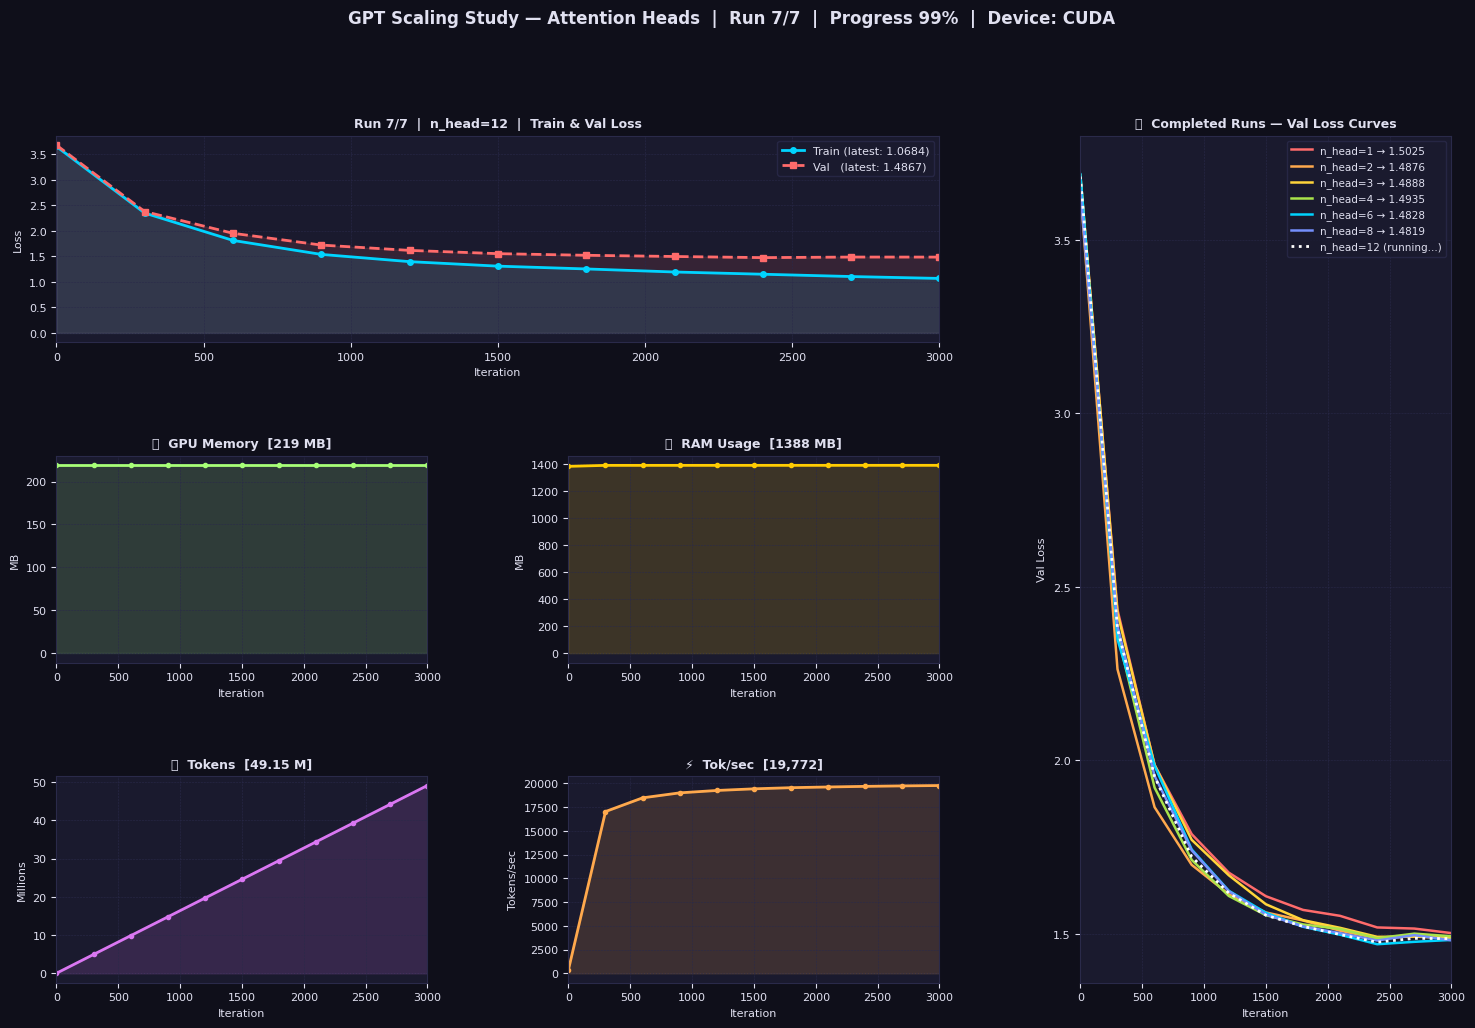

  iter 2999 | train 1.0684 | val 1.4867 | gpu 219MB | ram 1388MB | tokens 49.15M | tok/s 19,772

   Run 7 done | 41.5 min | final val: 1.4867

 All 7 runs complete!


In [7]:
# ── Cell 7: Main experiment loop with live dashboard ──────────────
all_results      = {}          # completed runs
tokens_per_batch = BATCH_SIZE * BLOCK_SIZE

for run_idx, cfg in enumerate(HEAD_CONFIGS):
    n_head = cfg['n_head']

    print(f'\n{"="*60}')
    print(f'RUN {run_idx+1}/{len(HEAD_CONFIGS)}  |  n_head={n_head}  |  head_size={cfg["head_size"]}')
    print(f'{"="*60}')

    torch.manual_seed(1337)
    if device == 'cuda': torch.cuda.manual_seed(1337)

    model     = GPTLanguageModel(n_head).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    n_params  = sum(p.numel() for p in model.parameters())
    print(f'Parameters : {n_params/1e6:.2f} M')

    # per-run logs
    iters_log    = []
    train_losses = []
    val_losses   = []
    gpu_mems     = []
    ram_usages   = []
    tokens_list  = []
    tok_rates    = []
    tokens_processed = 0
    t0 = time.time()

    for it in range(MAX_ITERS):

        # ── forward / backward ───────────────────────────────────
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        tokens_processed += tokens_per_batch

        # ── eval + dashboard update ───────────────────────────────
        if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:
            losses  = estimate_loss(model)
            elapsed = time.time() - t0

            gpu_mb  = torch.cuda.memory_allocated()/1e6 if device=='cuda' else 0.0
            ram_mb  = psutil.Process().memory_info().rss / 1e6
            tok_s   = tokens_processed / elapsed

            iters_log.append(it)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            gpu_mems.append(gpu_mb)
            ram_usages.append(ram_mb)
            tokens_list.append(tokens_processed)
            tok_rates.append(tok_s)

            # print text log below the plot
            live_dashboard(
                run_idx, n_head,
                iters_log, train_losses, val_losses,
                gpu_mems, ram_usages, tokens_list, tok_rates,
                all_results
            )
            print(
                f'  iter {it:>4} | '
                f'train {losses["train"]:.4f} | '
                f'val {losses["val"]:.4f} | '
                f'gpu {gpu_mb:.0f}MB | '
                f'ram {ram_mb:.0f}MB | '
                f'tokens {tokens_processed/1e6:.2f}M | '
                f'tok/s {tok_s:,.0f}'
            )

    elapsed = time.time() - t0

    # ── store completed run ───────────────────────────────────────
    all_results[n_head] = {
        'n_head'          : n_head,
        'head_size'       : cfg['head_size'],
        'n_params'        : n_params,
        'iters_log'       : iters_log,
        'train_losses'    : train_losses,
        'val_losses'      : val_losses,
        'gpu_mems'        : gpu_mems,
        'ram_usages'      : ram_usages,
        'tokens_list'     : tokens_list,
        'tok_rates'       : tok_rates,
        'final_train'     : train_losses[-1],
        'final_val'       : val_losses[-1],
        'tokens_processed': tokens_processed,
        'elapsed_sec'     : elapsed,
        'tok_per_sec'     : tokens_processed / elapsed,
    }

    # auto-save after every run
    with open('scaling_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)

    del model, optimizer
    if device == 'cuda': torch.cuda.empty_cache()

    print(f'\n   Run {run_idx+1} done | {elapsed/60:.1f} min | final val: {val_losses[-1]:.4f}')

print('\n All 7 runs complete!')

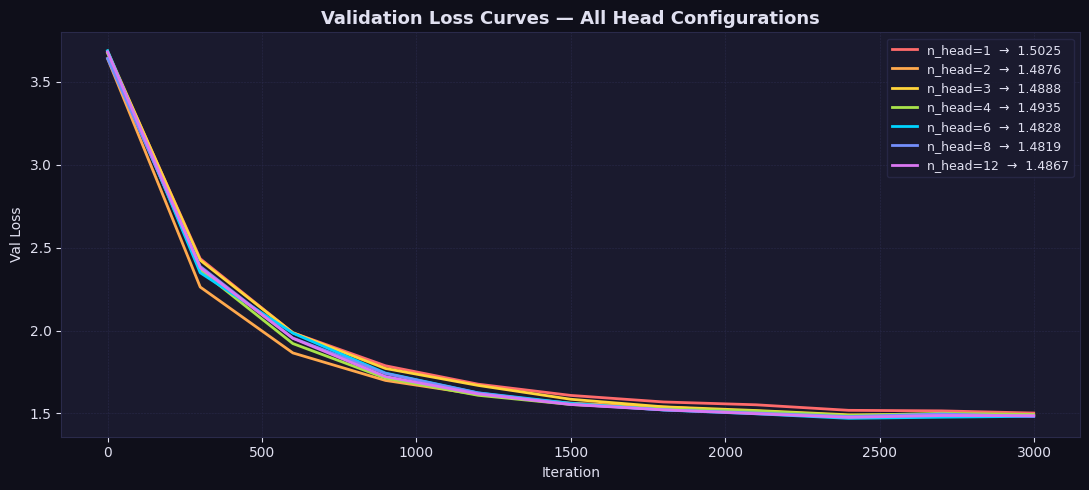

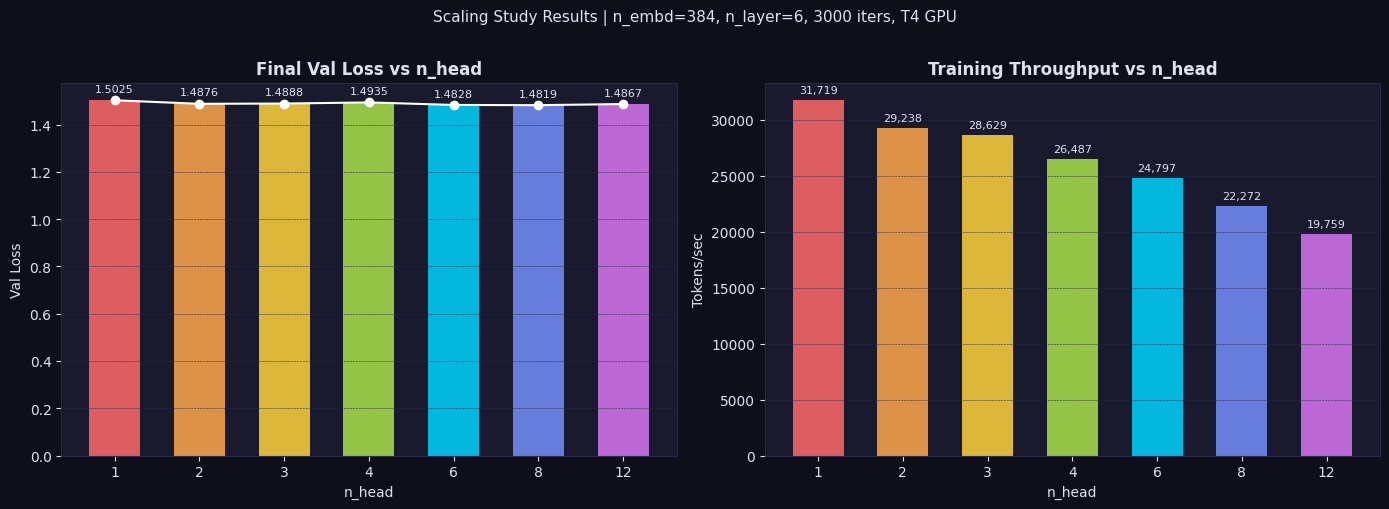


 Saved: fig1_val_curves.png  |  fig2_summary.png


In [8]:
# ── Cell 8: Final publication figures ─────────────────────────────
with open('scaling_results.json') as f:
    all_results = json.load(f)

results_list = sorted(all_results.values(), key=lambda r: r['n_head'])

# Figure 1: all val loss curves overlaid
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, linewidth=0.4, linestyle='--')
for i, r in enumerate(results_list):
    ax.plot(r['iters_log'], r['val_losses'], color=COLORS[i], lw=2,
            label=f"n_head={r['n_head']}  →  {r['final_val']:.4f}")
ax.set_title('Validation Loss Curves — All Head Configurations', color=TXT, fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration', color=TXT); ax.set_ylabel('Val Loss', color=TXT)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.savefig('fig1_val_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

# Figure 2: final val loss + throughput bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
n_heads_x  = [r['n_head']      for r in results_list]
final_vals = [r['final_val']   for r in results_list]
tok_rates  = [r['tok_per_sec'] for r in results_list]
bar_colors = [COLORS[i % len(COLORS)] for i in range(len(n_heads_x))]

for ax in axes:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=TXT)
    ax.grid(True, color=GRID, linewidth=0.4, linestyle='--', axis='y')

axes[0].bar([str(n) for n in n_heads_x], final_vals, color=bar_colors, alpha=0.85, width=0.6)
axes[0].plot([str(n) for n in n_heads_x], final_vals, color='white', lw=1.5, marker='o', ms=6, zorder=5)
for x, y in zip(n_heads_x, final_vals):
    axes[0].annotate(f'{y:.4f}', (str(x), y), textcoords='offset points',
                     xytext=(0, 6), ha='center', color=TXT, fontsize=8)
axes[0].set_title('Final Val Loss vs n_head', color=TXT, fontsize=12, fontweight='bold')
axes[0].set_xlabel('n_head', color=TXT); axes[0].set_ylabel('Val Loss', color=TXT)

axes[1].bar([str(n) for n in n_heads_x], tok_rates, color=bar_colors, alpha=0.85, width=0.6)
for x, y in zip(n_heads_x, tok_rates):
    axes[1].annotate(f'{y:,.0f}', (str(x), y), textcoords='offset points',
                     xytext=(0, 5), ha='center', color=TXT, fontsize=8)
axes[1].set_title('Training Throughput vs n_head', color=TXT, fontsize=12, fontweight='bold')
axes[1].set_xlabel('n_head', color=TXT); axes[1].set_ylabel('Tokens/sec', color=TXT)

fig.suptitle('Scaling Study Results | n_embd=384, n_layer=6, 3000 iters, T4 GPU',
             color=TXT, fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('fig2_summary.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

print('\n Saved: fig1_val_curves.png  |  fig2_summary.png')

In [9]:
# ── Cell 9: Results table ─────────────────────────────────────────
with open('scaling_results.json') as f:
    all_results = json.load(f)
results_list = sorted(all_results.values(), key=lambda r: r['n_head'])

best_val   = min(r['final_val']   for r in results_list)
best_speed = max(r['tok_per_sec'] for r in results_list)

print(f'\n{"─"*85}')
print(f'{"n_head":>8} | {"head_size":>10} | {"params(M)":>10} | '
      f'{"train loss":>11} | {"val loss":>10} | {"tok/s":>10}')
print(f'{"─"*85}')
for r in results_list:
    tag = ''
    if abs(r['final_val']   - best_val)   < 1e-6: tag += ' ← best loss'
    if abs(r['tok_per_sec'] - best_speed) < 1.0:  tag += ' ← fastest'
    print(f'{r["n_head"]:>8} | {r["head_size"]:>10} | '
          f'{r["n_params"]/1e6:>10.2f} | '
          f'{r["final_train"]:>11.4f} | '
          f'{r["final_val"]:>10.4f}{tag}')
print(f'{"─"*85}')

best = min(results_list, key=lambda r: r['final_val'])
print(f'\nBest: n_head={best["n_head"]} (head_size={best["head_size"]}) → val loss = {best["final_val"]:.4f}')


─────────────────────────────────────────────────────────────────────────────────────
  n_head |  head_size |  params(M) |  train loss |   val loss |      tok/s
─────────────────────────────────────────────────────────────────────────────────────
       1 |        384 |      10.79 |      1.1963 |     1.5025 ← fastest
       2 |        192 |      10.79 |      1.1208 |     1.4876
       3 |        128 |      10.79 |      1.1418 |     1.4888
       4 |         96 |      10.79 |      1.0935 |     1.4935
       6 |         64 |      10.79 |      1.1228 |     1.4828
       8 |         48 |      10.79 |      1.1066 |     1.4819 ← best loss
      12 |         32 |      10.79 |      1.0684 |     1.4867
─────────────────────────────────────────────────────────────────────────────────────

Best: n_head=8 (head_size=48) → val loss = 1.4819
